In [2]:
!kaggle datasets download ealaxi/paysim1

Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
paysim1.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import os
os.listdir("/content")


['.config', 'paysim1.zip', 'data', 'sample_data']

In [4]:
!unzip paysim1.zip -d data

Archive:  paysim1.zip
replace data/PS_20174392719_1491204439457_log.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/PS_20174392719_1491204439457_log.csv  y


y
y
y
y
y



In [5]:
import os
dataset_path = os.listdir("/content/data")[0]
dataset_path

'PS_20174392719_1491204439457_log.csv'

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
data = pd.read_csv('/content/data/'+dataset_path)
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [11]:
data['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


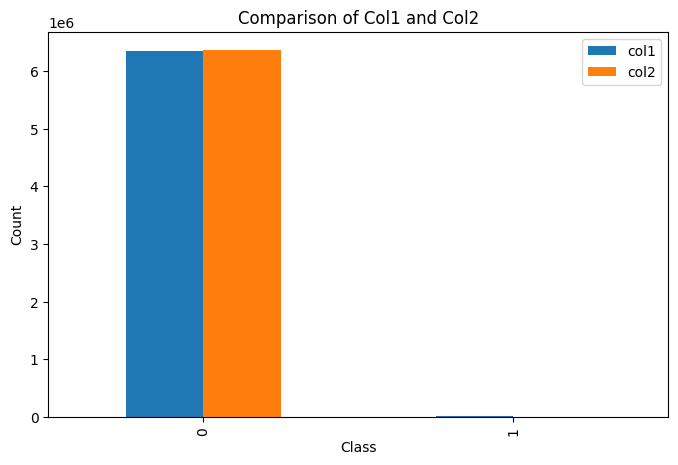

In [12]:
counts = pd.DataFrame({
    "col1": data["isFraud"].value_counts().sort_index(),
    "col2": data["isFlaggedFraud"].value_counts().sort_index()
})

counts.plot(kind="bar", figsize=(8,5))

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Comparison of Col1 and Col2")
plt.show()

In [13]:
counts.head()

,col1,col2
0,6354407,6362604
1,8213,16


In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.isna().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [16]:
pd.crosstab(
    data["isFraud"],
    data["isFlaggedFraud"]
)

isFlaggedFraud,0,1
isFraud,,
0,6354407,0
1,8197,16


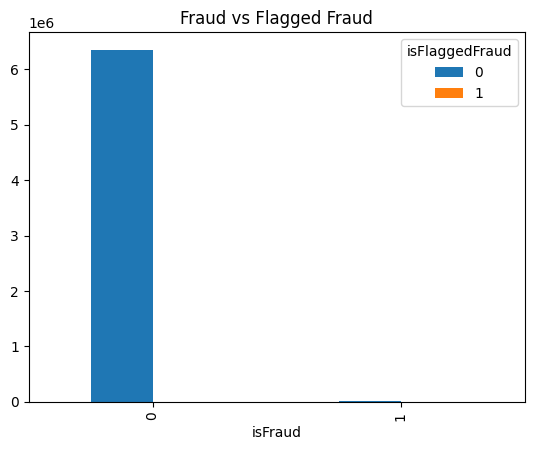

In [17]:
pd.crosstab(
    data["isFraud"],
    data["isFlaggedFraud"]
).plot(kind="bar")

plt.title("Fraud vs Flagged Fraud")
plt.show()

In [18]:
df = data.copy()

In [19]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [20]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [21]:
df['oldbalanceDest'].value_counts()

,count
oldbalanceDest,
0.00,2704388
10000000.00,615
20000000.00,219
30000000.00,86
40000000.00,31
...,...
2039554.04,1
587552.25,1
1326910.11,1


In [22]:
df['newbalanceOrig'].value_counts()

,count
newbalanceOrig,
0.00,3609566
7468.59,4
45633.24,4
7802.01,4
16828.17,4
...,...
2509.26,1
17671.03,1
36382.23,1


<Axes: xlabel='amount', ylabel='Count'>

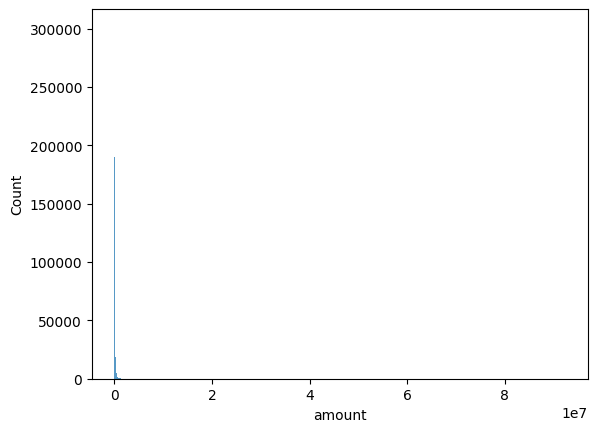

In [23]:
sns.histplot(df['amount'])

<Axes: xlabel='count', ylabel='type'>

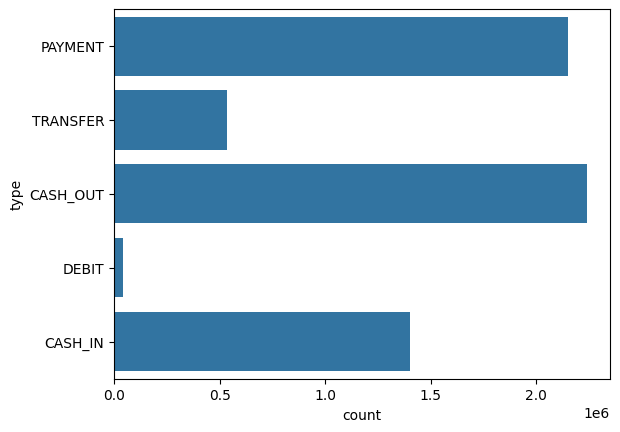

In [24]:
sns.countplot(df['type'])

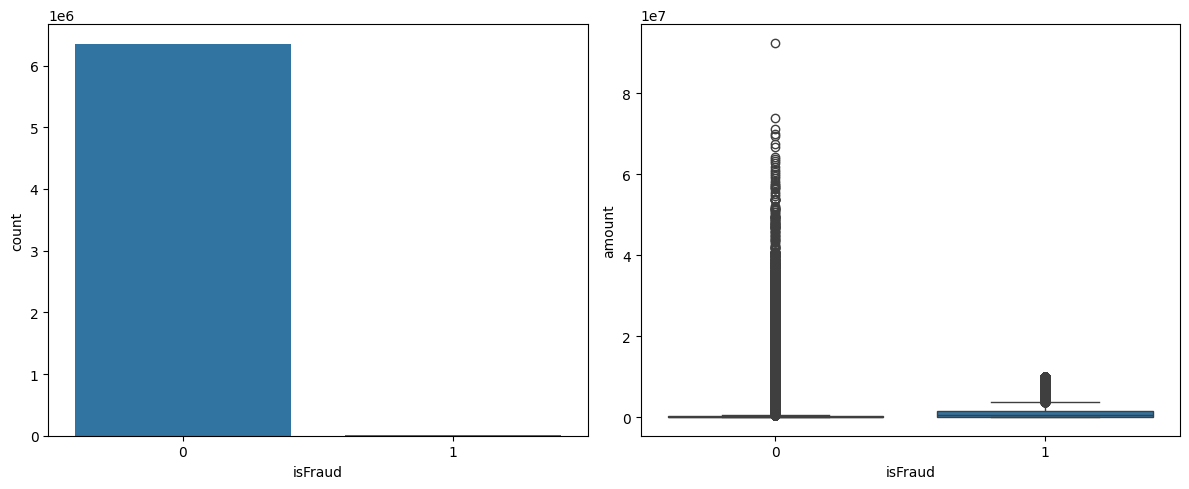

In [25]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.countplot(
    data=df,
    x='isFraud',
    ax=ax[0]
)

sns.boxplot(
    data=df,
    x='isFraud',
    y='amount',
    ax=ax[1]
)

plt.tight_layout()
plt.show()

In [26]:
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0,99.870918
1,0.129082


In [27]:
fraud_rate = (
    df.groupby('type')['isFraud']
    .mean()
    .sort_values(ascending=False)
)

print(fraud_rate)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [30]:
df['nameOrig'].value_counts()

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
...,...
C1567523029,1
C644777639,1
C1256645416,1


In [32]:
df['nameOrig'].duplicated().sum()

np.int64(9313)

In [34]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.shape

(6362620, 11)

In [35]:
df[df['newbalanceOrig'] == 0]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.0,M1176932104,0.00,0.00,0,0
10,1,DEBIT,9644.94,C1900366749,4465.00,0.0,C997608398,10845.00,157982.12,0,0
13,1,PAYMENT,11633.76,C1716932897,10127.00,0.0,M801569151,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


In [38]:
df['orig_zero_after'] = (df['newbalanceOrig'] == 0).astype(int)

In [39]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_zero_after
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0


In [40]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [41]:
df['orig_diff'] = (df['oldbalanceOrg'] - df['amount']) - df['newbalanceOrig']

df['dest_diff'] = (df['oldbalanceDest'] + df['amount']) - df['newbalanceDest']

In [42]:
df['dest_zero_before'] = (df['oldbalanceDest'] == 0).astype(int)

In [43]:
df['amount_balance_ratio'] = (
    df['amount'] / (df['oldbalanceOrg'] + 1)
)

In [44]:
df['account_drained'] = (
    (df['newbalanceOrig'] == 0) &
    (df['oldbalanceOrg'] > 0)
).astype(int)

In [45]:
df.drop(
    ['nameOrig', 'nameDest'],
    axis=1,
    inplace=True
)

In [46]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_zero_after,orig_diff,dest_diff,dest_zero_before,amount_balance_ratio,account_drained
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,0,0.0,9839.64,1,0.057834,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,0,0.0,1864.28,1,0.087731,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,1,0.0,181.00,1,0.994505,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,1,0.0,21363.00,0,0.994505,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,0,0.0,11668.14,1,0.280788,0


In [49]:
# print(df['isFlaggedFraud'].value_counts())

print(
    pd.crosstab(
        df['isFlaggedFraud'],
        df['isFraud']
    )
)

isFraud               0     1
isFlaggedFraud               
0               6354407  8197
1                     0    16


In [47]:
df.shape

(6362620, 15)

In [50]:
df.drop(
    'isFlaggedFraud',
    axis=1,
    inplace=True
)

In [51]:
df = pd.get_dummies(
    df,
    columns=['type'],
    drop_first=True
)

In [52]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_zero_after,orig_diff,dest_diff,dest_zero_before,amount_balance_ratio,account_drained,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,9839.64,1,0.057834,0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0.0,1864.28,1,0.087731,0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,1,0.0,181.00,1,0.994505,1,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,1,0.0,21363.00,0,0.994505,1,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.0,11668.14,1,0.280788,0,False,False,True,False


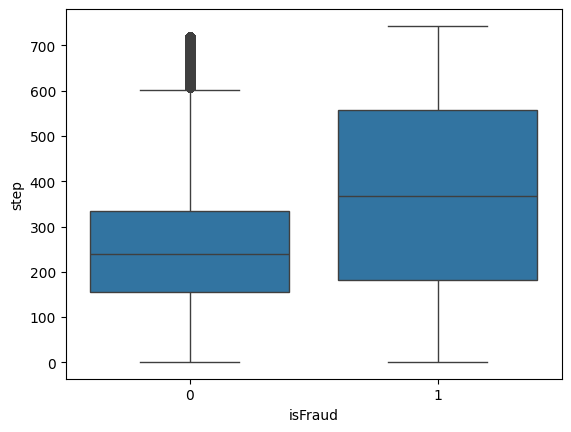

In [53]:
sns.boxplot(
    x='isFraud',
    y='step',
    data=df
)

plt.show()

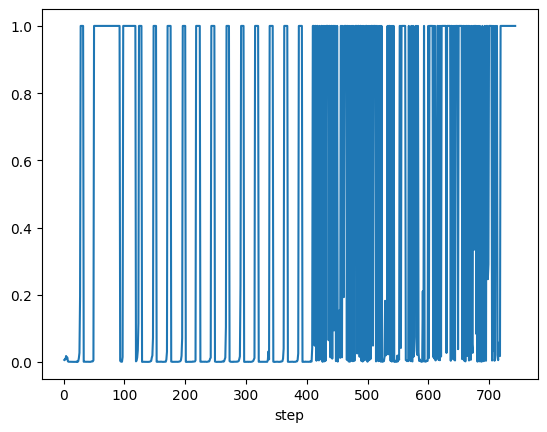

In [54]:
df.groupby('step')['isFraud'].mean().plot()
plt.show()

In [55]:
df['day'] = df['step'] // 24
df['hour'] = df['step'] % 24

In [56]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_zero_after,orig_diff,dest_diff,dest_zero_before,amount_balance_ratio,account_drained,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,day,hour
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,0.0,9839.64,1,0.057834,0,False,False,True,False,0,1
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,0.0,1864.28,1,0.087731,0,False,False,True,False,0,1
2,1,181.00,181.0,0.00,0.0,0.0,1,1,0.0,181.00,1,0.994505,1,False,False,False,True,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,1,0.0,21363.00,0,0.994505,1,True,False,False,False,0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,0.0,11668.14,1,0.280788,0,False,False,True,False,0,1


In [64]:
df.drop('step', axis=1, inplace=True)

In [62]:
print(df['day'].value_counts())
df['hour'].value_counts()

day
0     571039
1     452761
7     449147
5     440626
12    429335
16    421098
6     420282
8     418103
10    418006
14    400706
13    398210
9     392886
15    375514
11    349800
24     58712
28     55037
21     52510
22     50432
23     33349
17     29251
20     24589
3      21904
19     19739
27     14522
25     13893
4      12995
18     11286
29     11283
26      8574
2       6749
30       282
Name: count, dtype: int64


,count
hour,
19,647814
18,580509
20,553728
12,483418
13,468474
11,445992
16,441612
17,439941
14,439653


(array([ 107716.,    3248.,    5061.,  319421.,  871721.,  951892.,
        1297951., 1020450., 1201542.,  583618.]),
 array([ 0. ,  2.3,  4.6,  6.9,  9.2, 11.5, 13.8, 16.1, 18.4, 20.7, 23. ]),
 <BarContainer object of 10 artists>)

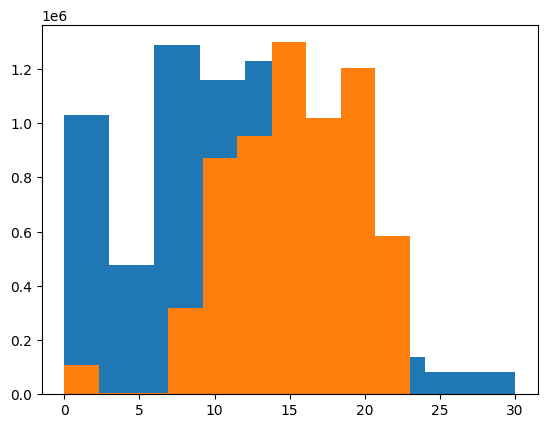

In [61]:
plt.hist(df['day'],histtype='bar')
plt.hist(df['hour'],histtype='barstacked')

In [70]:
corr = df.corr(numeric_only=True)

corr['isFraud'].sort_values(ascending=False)

,isFraud
isFraud,1.000000
amount,0.076688
account_drained,0.062091
dest_diff,0.055120
type_TRANSFER,0.053869
day,0.032577
orig_zero_after,0.029984
dest_zero_before,0.016471
orig_diff,0.011283
type_CASH_OUT,0.011256


<Axes: >

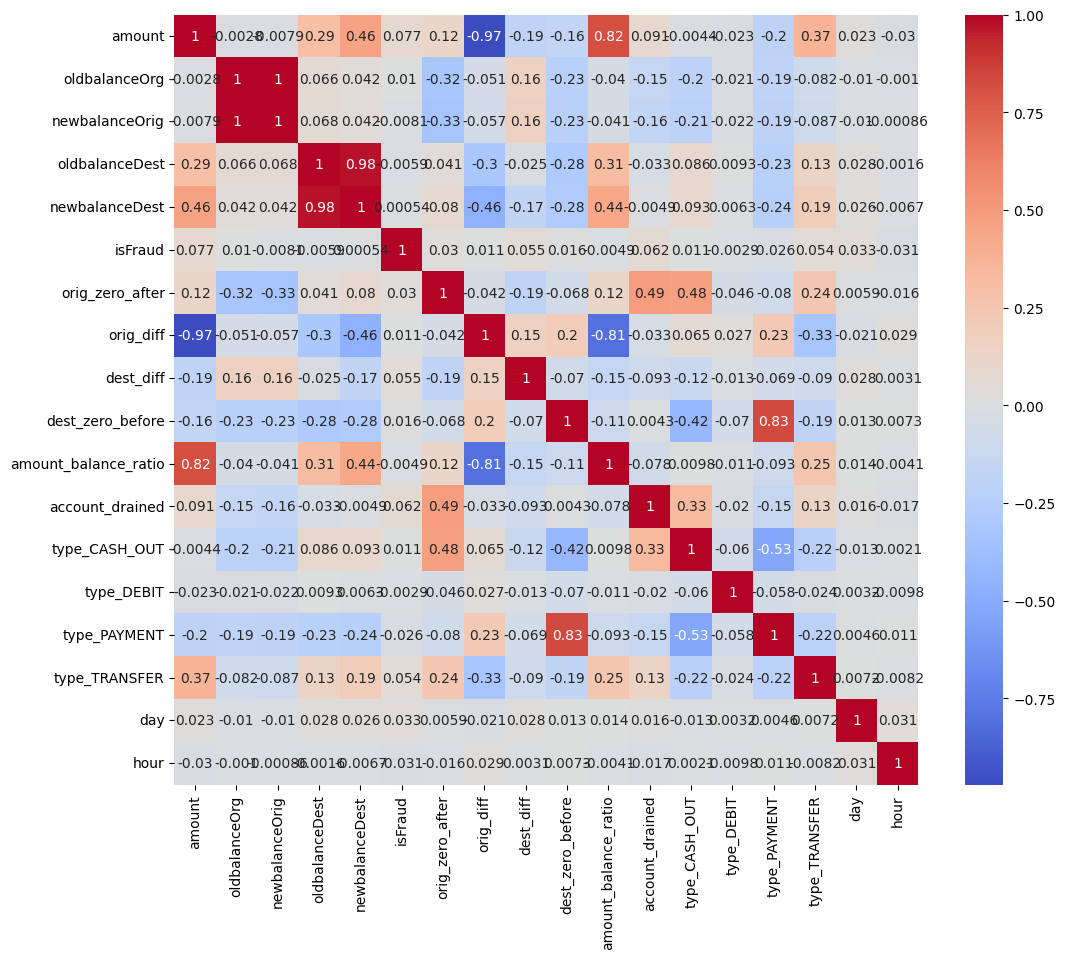

In [71]:
plt.figure(figsize=(12,10))
sns.heatmap(corr,cmap='coolwarm', annot=True)

In [69]:
df.columns == 'step'

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False])

In [72]:
X = df.drop(['isFraud'], axis=1)

y = df['isFraud']

In [73]:
X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_zero_after,orig_diff,dest_diff,dest_zero_before,amount_balance_ratio,account_drained,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,day,hour
0,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64,1,0.057834,0,False,False,True,False,0,1
1,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28,1,0.087731,0,False,False,True,False,0,1
2,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00,1,0.994505,1,False,False,False,True,0,1
3,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00,0,0.994505,1,True,False,False,False,0,1
4,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14,1,0.280788,0,False,False,True,False,0,1


In [74]:
X.shape

(6362620, 17)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   amount                float64
 1   oldbalanceOrg         float64
 2   newbalanceOrig        float64
 3   oldbalanceDest        float64
 4   newbalanceDest        float64
 5   isFraud               int64  
 6   orig_zero_after       int64  
 7   orig_diff             float64
 8   dest_diff             float64
 9   dest_zero_before      int64  
 10  amount_balance_ratio  float64
 11  account_drained       int64  
 12  type_CASH_OUT         bool   
 13  type_DEBIT            bool   
 14  type_PAYMENT          bool   
 15  type_TRANSFER         bool   
 16  day                   int64  
 17  hour                  int64  
dtypes: bool(4), float64(8), int64(6)
memory usage: 703.9 MB


In [76]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype('int8')

In [77]:
bool_cols

Index(['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'], dtype='object')

In [78]:
float_cols = df.select_dtypes(include='float64').columns
int_cols = df.select_dtypes(include='int64').columns
print(float_cols)
print(int_cols)



Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'orig_diff', 'dest_diff', 'amount_balance_ratio'],
      dtype='object')
Index(['isFraud', 'orig_zero_after', 'dest_zero_before', 'account_drained',
       'day', 'hour'],
      dtype='object')


In [79]:

df[float_cols] = df[float_cols].astype('float32')
df[int_cols] = df[int_cols].astype('int32')

In [80]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 18 columns):
 #   Column                Dtype  
---  ------                -----  
 0   amount                float32
 1   oldbalanceOrg         float32
 2   newbalanceOrig        float32
 3   oldbalanceDest        float32
 4   newbalanceDest        float32
 5   isFraud               int32  
 6   orig_zero_after       int32  
 7   orig_diff             float32
 8   dest_diff             float32
 9   dest_zero_before      int32  
 10  amount_balance_ratio  float32
 11  account_drained       int32  
 12  type_CASH_OUT         int8   
 13  type_DEBIT            int8   
 14  type_PAYMENT          int8   
 15  type_TRANSFER         int8   
 16  day                   int32  
 17  hour                  int32  
dtypes: float32(8), int32(6), int8(4)
memory usage: 364.1 MB


In [81]:
df.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,orig_zero_after,orig_diff,dest_diff,dest_zero_before,amount_balance_ratio,account_drained,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,day,hour
0,9839.639648,170136.0,160296.359375,0.0,0.0,0,0,0.0,9839.639648,1,0.057834,0,0,0,1,0,0,1
1,1864.280029,21249.0,19384.720703,0.0,0.0,0,0,0.0,1864.280029,1,0.087731,0,0,0,1,0,0,1
2,181.000000,181.0,0.000000,0.0,0.0,1,1,0.0,181.000000,1,0.994505,1,0,0,0,1,0,1
3,181.000000,181.0,0.000000,21182.0,0.0,1,1,0.0,21363.000000,0,0.994505,1,1,0,0,0,0,1
4,11668.139648,41554.0,29885.859375,0.0,0.0,0,0,0.0,11668.139648,1,0.280788,0,0,0,1,0,0,1


In [107]:
X.columns.tolist()

['amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'orig_zero_after',
 'orig_diff',
 'dest_diff',
 'dest_zero_before',
 'amount_balance_ratio',
 'account_drained',
 'type_CASH_OUT',
 'type_DEBIT',
 'type_PAYMENT',
 'type_TRANSFER',
 'day',
 'hour']

In [91]:
X.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_zero_after,orig_diff,dest_diff,dest_zero_before,amount_balance_ratio,account_drained,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,day,hour
0,9839.64,170136.0,160296.36,0.0,0.0,0,0.0,9839.64,1,0.057834,0,False,False,True,False,0,1
1,1864.28,21249.0,19384.72,0.0,0.0,0,0.0,1864.28,1,0.087731,0,False,False,True,False,0,1
2,181.00,181.0,0.00,0.0,0.0,1,0.0,181.00,1,0.994505,1,False,False,False,True,0,1
3,181.00,181.0,0.00,21182.0,0.0,1,0.0,21363.00,0,0.994505,1,True,False,False,False,0,1
4,11668.14,41554.0,29885.86,0.0,0.0,0,0.0,11668.14,1,0.280788,0,False,False,True,False,0,1


In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5090096, 17), (1272524, 17), (5090096,), (1272524,))

In [84]:
y_train.value_counts()

,count
isFraud,
0,5083526
1,6570


In [85]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [87]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [88]:
y_pred_rf = rf.predict(X_test)
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1270881       0]
 [      4    1639]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



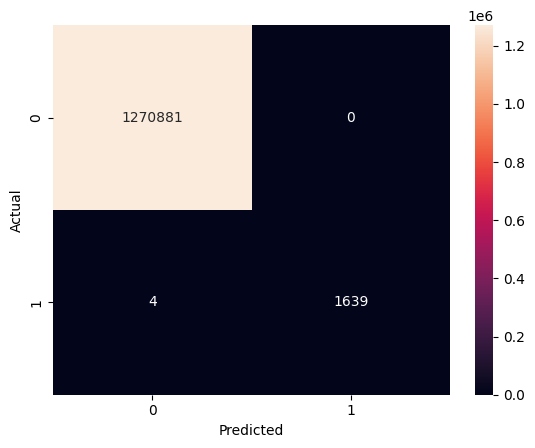

In [90]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [95]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred_rf))

0.9999968566408177


In [94]:
risk_score = rf.predict_proba(X_test)[:,1] * 100

In [100]:
len(risk_score)

1272524

### Fraud Prediction Function

This function takes a new DataFrame of transaction data, applies all the necessary feature engineering and preprocessing steps, and then uses the trained Random Forest model to predict whether each transaction is fraudulent.

In [101]:
def predict_fraud(new_data_df, model):
    df_processed = new_data_df.copy()

    # Feature Engineering (same as applied to training data)
    df_processed['orig_zero_after'] = (df_processed['newbalanceOrig'] == 0).astype(int)
    df_processed['orig_diff'] = (df_processed['oldbalanceOrg'] - df_processed['amount']) - df_processed['newbalanceOrig']
    df_processed['dest_diff'] = (df_processed['oldbalanceDest'] + df_processed['amount']) - df_processed['newbalanceDest']
    df_processed['dest_zero_before'] = (df_processed['oldbalanceDest'] == 0).astype(int)
    # Add 1 to oldbalanceOrg to avoid division by zero
    df_processed['amount_balance_ratio'] = df_processed['amount'] / (df_processed['oldbalanceOrg'] + 1)
    df_processed['account_drained'] = ((df_processed['newbalanceOrig'] == 0) & (df_processed['oldbalanceOrg'] > 0)).astype(int)
    df_processed['day'] = df_processed['step'] // 24
    df_processed['hour'] = df_processed['step'] % 24

    # Drop original 'step' and identifier columns
    df_processed.drop(
        ['step', 'nameOrig', 'nameDest', 'isFlaggedFraud'],
        axis=1,
        inplace=True,
        errors='ignore' # Use errors='ignore' in case some columns are already dropped
    )

    # One-hot encode 'type' column
    df_processed = pd.get_dummies(
        df_processed,
        columns=['type'],
        drop_first=True
    )

    # Ensure all type columns exist, filling with 0 if not present in new data
    expected_type_cols = ['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
    for col in expected_type_cols:
        if col not in df_processed.columns:
            df_processed[col] = 0

    # Convert boolean columns to int8
    bool_cols_processed = df_processed.select_dtypes(include='bool').columns
    df_processed[bool_cols_processed] = df_processed[bool_cols_processed].astype('int8')

    # Convert float and int columns to float32 and int32
    # Exclude 'isFraud' if it exists, as it's the target and might not be present in new data without labels
    float_cols_processed = df_processed.select_dtypes(include='float64').columns
    int_cols_processed = df_processed.select_dtypes(include='int64').columns
    df_processed[float_cols_processed] = df_processed[float_cols_processed].astype('float32')
    df_processed[int_cols_processed] = df_processed[int_cols_processed].astype('int32')

    # Align columns with training data (X_train) to handle missing columns or extra columns
    # Assuming X_train's columns are the definitive set of features
    final_columns = X_train.columns
    missing_cols = set(final_columns) - set(df_processed.columns)
    for c in missing_cols:
        df_processed[c] = 0 # Fill missing columns with 0

    df_processed = df_processed[final_columns] # Ensure the order of columns is the same

    # Predict fraud
    predictions = model.predict(df_processed)
    probabilities = model.predict_proba(df_processed)[:, 1]

    return predictions, probabilities

In [111]:
import pandas as pd

def predict_fraud(new_data_df, model, feature_columns):
    """
    Predict fraud for new transactions.

    Parameters:
    -----------
    new_data_df : pd.DataFrame
        Raw transaction data.

    model : Trained ML model
        Example: RandomForestClassifier

    feature_columns : list
        List of feature names used during training.
        Example:
        feature_columns = X.columns.tolist()

    Returns:
    --------
    predictions : Fraud prediction (0 or 1)

    probabilities : Fraud probability

    risk_scores : Risk score from 0-100

    labels : Human-readable prediction
    """

    # =====================================================
    # Create a copy to avoid modifying original dataframe
    # =====================================================
    df_processed = new_data_df.copy()

    # =====================================================
    # Feature Engineering
    # Same transformations used during training
    # =====================================================

    # 1. Was the source account emptied?
    df_processed['orig_zero_after'] = (
        df_processed['newbalanceOrig'] == 0
    ).astype(int)

    # 2. Difference between expected and actual source balance
    df_processed['orig_diff'] = (
        (df_processed['oldbalanceOrg'] - df_processed['amount'])
        - df_processed['newbalanceOrig']
    )

    # 3. Difference between expected and actual destination balance
    df_processed['dest_diff'] = (
        (df_processed['oldbalanceDest'] + df_processed['amount'])
        - df_processed['newbalanceDest']
    )

    # 4. Was destination account empty before transaction?
    df_processed['dest_zero_before'] = (
        df_processed['oldbalanceDest'] == 0
    ).astype(int)

    # 5. Amount relative to account balance
    # +1 prevents division by zero
    df_processed['amount_balance_ratio'] = (
        df_processed['amount']
        / (df_processed['oldbalanceOrg'] + 1)
    )

    # 6. Did transaction drain the account?
    df_processed['account_drained'] = (
        (df_processed['newbalanceOrig'] == 0)
        & (df_processed['oldbalanceOrg'] > 0)
    ).astype(int)

    # =====================================================
    # Create time-based features
    # =====================================================

    # Day number
    df_processed['day'] = df_processed['step'] // 24

    # Hour of day
    df_processed['hour'] = df_processed['step'] % 24

    # =====================================================
    # Remove columns not used for training
    # =====================================================
    df_processed.drop(
        [
            'step',
            'nameOrig',
            'nameDest',
            'isFlaggedFraud'
        ],
        axis=1,
        inplace=True,
        errors='ignore'
    )

    # =====================================================
    # One-Hot Encode Transaction Type
    # =====================================================
    df_processed = pd.get_dummies(
        df_processed,
        columns=['type'],
        drop_first=True
    )

    # =====================================================
    # Align columns with training dataset
    # Adds missing columns and keeps correct order
    # =====================================================
    df_processed = df_processed.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # =====================================================
    # Convert boolean columns to integers
    # =====================================================
    bool_cols = df_processed.select_dtypes(
        include='bool'
    ).columns

    df_processed[bool_cols] = (
        df_processed[bool_cols]
        .astype('int8')
    )

    # =====================================================
    # Optional memory optimization
    # =====================================================
    float_cols = df_processed.select_dtypes(
        include='float64'
    ).columns

    int_cols = df_processed.select_dtypes(
        include='int64'
    ).columns

    df_processed[float_cols] = (
        df_processed[float_cols]
        .astype('float32')
    )

    df_processed[int_cols] = (
        df_processed[int_cols]
        .astype('int32')
    )

    # =====================================================
    # Make predictions
    # =====================================================
    predictions = model.predict(df_processed)

    # Fraud probability
    probabilities = model.predict_proba(
        df_processed
    )[:, 1]

    # Convert probability into risk score
    risk_scores = probabilities * 100

    # Human-readable labels
    labels = [
        "Fraud" if pred == 1 else "Legitimate"
        for pred in predictions
    ]

    # =====================================================
    # Return results
    # =====================================================
    return (
        predictions,
        probabilities,
        risk_scores,
        labels
    )

### Example Usage of `predict_fraud` Function

Let's test the `predict_fraud` function with a sample transaction. We'll create a synthetic transaction that looks like a fraudulent transfer to see if our model flags it.

In [102]:
# Create a sample transaction data that is likely fraudulent
# (e.g., TRANSFER with oldbalanceOrg -> 0 and newbalanceDest high)
fraud_example = pd.DataFrame([
    {
        'step': 100,
        'type': 'TRANSFER',
        'amount': 100000.00,
        'nameOrig': 'C1234567890',
        'oldbalanceOrg': 100000.00,
        'newbalanceOrig': 0.00,
        'nameDest': 'C0987654321',
        'oldbalanceDest': 0.00,
        'newbalanceDest': 100000.00,
        'isFraud': 0, # We don't know yet, setting to 0 for consistency with original df structure
        'isFlaggedFraud': 0
    },
    {
        'step': 50,
        'type': 'PAYMENT',
        'amount': 500.00,
        'nameOrig': 'C1111111111',
        'oldbalanceOrg': 1000.00,
        'newbalanceOrig': 500.00,
        'nameDest': 'M2222222222',
        'oldbalanceDest': 0.00,
        'newbalanceDest': 0.00,
        'isFraud': 0,
        'isFlaggedFraud': 0
    }
])

# Make predictions using the function
predictions, probabilities = predict_fraud(fraud_example, rf)

print("Predictions (0=Not Fraud, 1=Fraud):", predictions)
print("Fraud Probabilities:", probabilities)

# Display the example transaction with its prediction
fraud_example['predicted_fraud'] = predictions
fraud_example['fraud_probability'] = probabilities
display(fraud_example)

Predictions (0=Not Fraud, 1=Fraud): [1 0]
Fraud Probabilities: [0.98 0.  ]


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,predicted_fraud,fraud_probability
0,100,TRANSFER,100000.0,C1234567890,100000.0,0.0,C0987654321,0.0,100000.0,0,0,1,0.98
1,50,PAYMENT,500.0,C1111111111,1000.0,500.0,M2222222222,0.0,0.0,0,0,0,0.00


In [109]:
new_transaction = pd.DataFrame({
    "step": [100],
    "type": ["PAYMENT"],
    "amount": [5000],
    "nameOrig": ["C123456789"],
    "oldbalanceOrg": [50000],
    "newbalanceOrig": [45000],
    "nameDest": ["M987654321"],
    "oldbalanceDest": [0],
    "newbalanceDest": [0],
    "isFlaggedFraud": [0]
})

In [115]:
feature_columns = X.columns.tolist()
predictions, probabilities, risk_scores, labels = predict_fraud(
    new_data_df=new_transaction,
    model=rf,
    feature_columns=feature_columns
)

print("Prediction:", labels[0])
print("Fraud Probability:", probabilities[0])
print("Risk Score:", risk_scores[0])

['Legitimate']
Prediction: Legitimate
Fraud Probability: 0.0
Risk Score: 0.0


Experiment **2**

Removing esay cols

In [103]:
cols = [
    'orig_zero_after',
    'account_drained',
    'orig_diff',
    'dest_diff',
    'amount_balance_ratio'
]

X2 = X.drop(columns=cols)

In [104]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

np.float64(0.9990866630753574)

In [105]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance.head(10))

                 feature  importance
6              orig_diff    0.292304
9   amount_balance_ratio    0.201718
10       account_drained    0.144467
2         newbalanceOrig    0.104707
1          oldbalanceOrg    0.082969
5        orig_zero_after    0.057352
0                 amount    0.036864
13          type_PAYMENT    0.019098
7              dest_diff    0.017223
14         type_TRANSFER    0.012661


# SAVE MODEL

In [116]:
import joblib

joblib.dump(rf, "fraud_model.pkl")

['fraud_model.pkl']

In [117]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']